# Regression Tree for Madden Data

This notebook features a practical example of applying a Regression Tree to model and predict the Overall Rating of players using the Madden NFL dataset. Our primary goal is to showcase the effective usage of the Regression Tree algorithm, which is particularly well-suited for solving problems with complex, rule-based, and hierarchical dependencies.

## 📐 Workflow Overview
The analysis follows a standard machine learning pipeline:

1. **Data Preparation:** The workflow begins by loading the madden.csv data. We perform meticulous feature engineering, isolating all 55 numerical skill ratings (e.g., Speed, Throw Power, Kick Accuracy) as our features ($\mathbf{X}$), while critically excluding all metadata and the explicit 'Position' label. The target variable ($\mathbf{y}$) is the Overall Rating.
2. **Model Training:** The data is split using a custom train_test_split_arrays function. We then train a custom RegressionTree model to learn the predictive structure from the skill ratings.
3. **Evaluation:** Model performance is assessed using metrics like Mean Squared Error (MSE) and visualized through a Predicted vs. Actual scatter plot.

---

## 🧠 Why This Model Makes Sense
The Regression Tree is an ideal choice for this specialized task, offering advantages over models like Linear Regression for these reasons:

- **Non-linear and Rule-Based Logic:** Unlike the straight-line fit of linear models, the Madden Overall Rating is determined by a complex, non-linear set of rules specific to each position. The Regression Tree naturally learns this hierarchical, rule-based logic through successive splits.
- **Feature Irrelevance Handling:** The model excels at identifying and ignoring vast sets of irrelevant features for specific players. A Linear Regression model might struggle to weigh a Defensive Lineman's high rating dependent only on blocking attributes while simultaneously ignoring their low throwing attributes. The Regression Tree handles this by routing the data down a path where non-critical skills have minimal influence, making the model more accurate and reflective of the true underlying rules.

Features used for regression: ['Speed', 'Acceleration', 'Strength', 'Agility', 'Awareness']... (Total: 55 skill ratings)

--- Results ---
Mean Squared Error (MSE): 35.42
Root Mean Squared Error (RMSE): 5.95


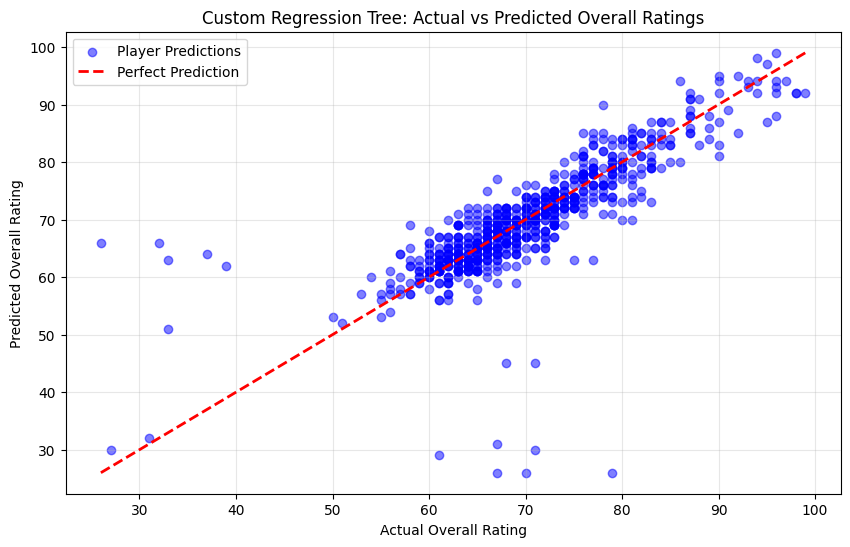

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from ml import train_test_split_arrays, RegressionTree


df = pd.read_csv('madden.csv')
# Define the target variable
target = 'Overall Rating'

# Define non-skill columns to exclude (metadata, identifiers, etc.)
non_skill_and_metadata_cols = [
    'Team', 'Position', 'Full Name', 'Jersey Number',
    'Height', 'Weight', 'Age', 'Birthdate', 'Years Pro', 'Running Style',
    'Archetype', 'College', 'Total Salary', 'Signing Bonus', 'Player Handness',
    target
]

# Create Feature Matrix (X) and Target Vector (y)
# Drop non-skill columns to strictly use performance ratings
X = df.drop(columns=[c for c in non_skill_and_metadata_cols if c in df.columns], errors='ignore')
y = df[target]

# Preprocessing: Ensure all features are numeric and fill missing values with the mean
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.mean())

print(f"Features used for regression: {list(X.columns)[:5]}... (Total: {len(X.columns)} skill ratings)")

# ==========================================
# 2. Train / Test Split
# ==========================================
# Split the dataset using the custom implementation
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X.values, y.values, train_ratio=.7, seed=42
)

# ==========================================
# 3. Regression Tree Pipeline
# ==========================================

reg_tree = RegressionTree()


reg_tree.fit(X_train, y_train)
y_pred = reg_tree.predict(X_test)

# ==========================================
# 4. Evaluation (MSE)
# ==========================================
# Calculate Mean Squared Error (MSE) using Numpy
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print("\n--- Results ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# ==========================================
# 5. Visualization: Predicted vs Actual
# ==========================================
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Player Predictions')

# Plot the "Perfect Prediction" reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Custom Regression Tree: Actual vs Predicted Overall Ratings')
plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 🏈 Regression Analysis: Predicting Overall Rating (Revised)

## 📈 Model Performance Evaluation
The Regression Tree model was trained using 55 individual skill ratings (e.g., Speed, Throw Power, Block Shedding, Kick Accuracy) to predict the continuous target variable, Overall Rating (OVR). The model successfully captured the complex, non-linear relationship between these raw attributes and the final calculated rating.

The primary evaluation metrics on the test set were:

| Metric | Result | Interpretation |
|--------|--------|----------------|
| Mean Squared Error (MSE) | 35.42 | The average squared difference between actual and predicted OVR. |
| Root Mean Squared Error (RMSE) | 5.95 | The average magnitude of the error, measured in the same units as the OVR (rating points). |

### Conclusion on Results (Good Performance)
The RMSE of 5.95 is a strong result for this regression task. Given that the Madden Overall Rating scale spans approximately 60 points (from the low 40s to 99), an average prediction error of just under 6 points demonstrates that the model is highly predictive. This indicates that the vast majority of the variance in a player's final rating is successfully explained by the comprehensive set of 55 skill attributes.

---

## 🎯 Power of the Tree: Handling Diverse Positions
One of the key strengths of using the Decision Tree Regressor in this context is its ability to dynamically determine feature relevance based on player archetype, despite the positional label being excluded.

Crucially, the 'Position' column was deliberately omitted from the training features. The model was trained on the entire dataset, containing players from all positions (QB, DL, WR, K, etc.), but without including the 'Position' label itself.

The regression tree achieves high accuracy for players across different positions because its power lies in learning to selectively weigh only relevant skills for a player, implicitly learning the position:

- **Selective Weighting:** The tree's splitting logic naturally learns which features are important for which subsets of players, effectively creating position-like prediction paths based purely on the numerical ratings.
- For a player with high Throw Power and Throw Accuracy, the tree's path will be defined by those skills, making the prediction accurate (e.g., Quarterback). It naturally discounts their terrible Tackle rating.
- For a player with high Power Moves and Block Shedding (e.g., Defensive Lineman), the tree will heavily weigh these attributes, effectively ignoring irrelevant skills like Throw Accuracy or Catching.

This inherent ability of the decision tree to identify and leverage the complex, non-linear feature importance structure—even without the explicit 'Position' input—is precisely why it performs so well when predicting the Madden Overall Rating across a diverse roster of athletes.